Exploratory Data Analysis (EDA).


Which transaction types are most associated with fraud?
What transaction amounts are typical for fraudulent activity?
Which receiver accounts appear most suspicious?
What insights should feed the Receiver Risk Engine?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)

df = pd.read_csv(r"D:\SecurePay-AI\dataset\cleaned\transactions_clean.csv")

In [2]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.tail()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
# fraud distribution analysis 

# how many transaction are fraudulent ?

df["isfraud"].value_counts()

isfraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
# fraud percentage 

fraud_percentage = (
    df["isfraud"].value_counts(normalize=True)*100
).round(2)

print(fraud_percentage)

isfraud
0    99.87
1     0.13
Name: proportion, dtype: float64


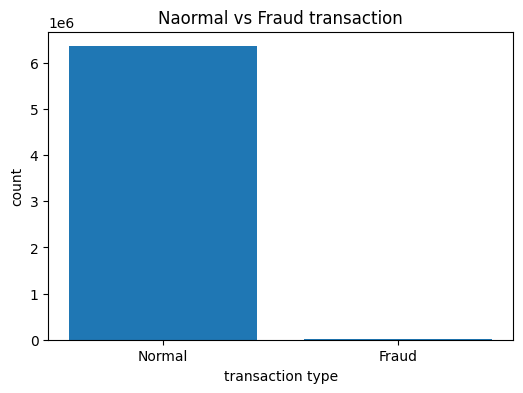

In [8]:
# count plot

fraud_count = df["isfraud"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["Normal","Fraud"],
    fraud_count.values
)

plt.title("Naormal vs Fraud transaction")
plt.xlabel("transaction type")
plt.ylabel("count")
plt.show()

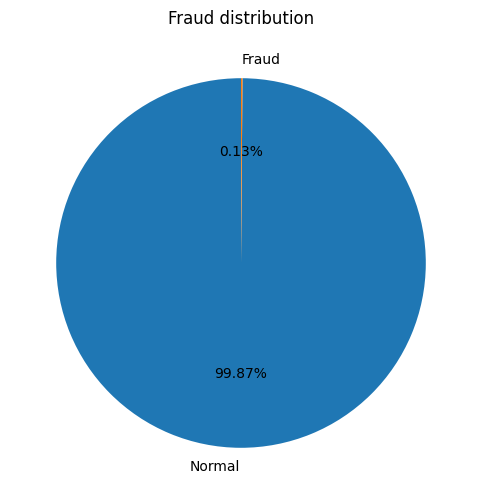

In [9]:
#pie chart 

plt.figure(figsize=(6,6))

plt.pie(
    fraud_count.values,
    labels=["Normal","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud distribution")
plt.show()

In [10]:
# Transaction Type Analysis

# most common transaction type 

df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [11]:
# fraud percentage by transaction type

fraud_table =(
    pd.crosstab(
        df["type"],
        df["isfraud"],
        normalize="index"
    )*100
)

fraud_table

isfraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


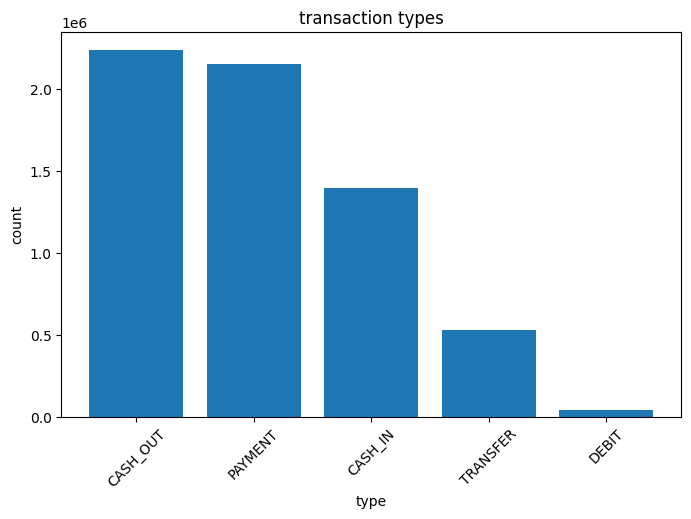

In [12]:
# transaction count 

transaction_counts = df["type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
     transaction_counts.index,
     transaction_counts.values
    )

plt.title("transaction types")
plt.xlabel("type")
plt.ylabel("count")
plt.xticks(rotation = 45)

plt.show()

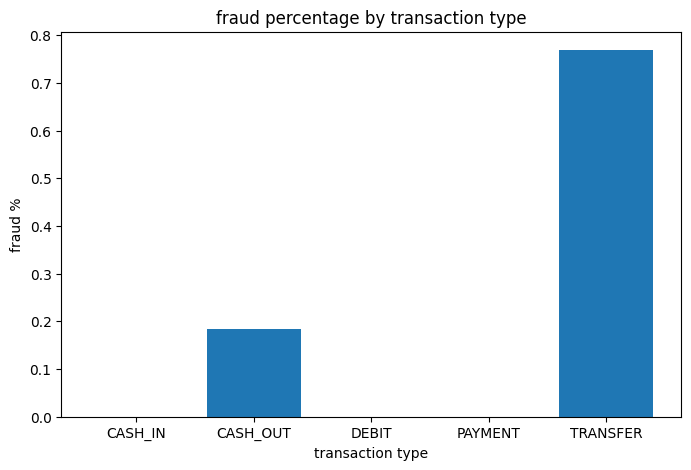

In [13]:
# fraud percentage 

fraud_percent = fraud_table[1]

plt.figure(figsize=(8,5))

plt.bar(
    fraud_percent.index,
    fraud_percent.values
)

plt.title("fraud percentage by transaction type")
plt.xlabel("transaction type")
plt.ylabel("fraud %")

plt.show()

In [17]:
# transaction amount analysis 

print("avg:",df["amount"].mean())
print("median:",df["amount"].median())
print("maximum:",df["amount"].max())
print("minimum:",df["amount"].min())

avg: 179861.90354913071
median: 74871.94
maximum: 92445516.64
minimum: 0.0


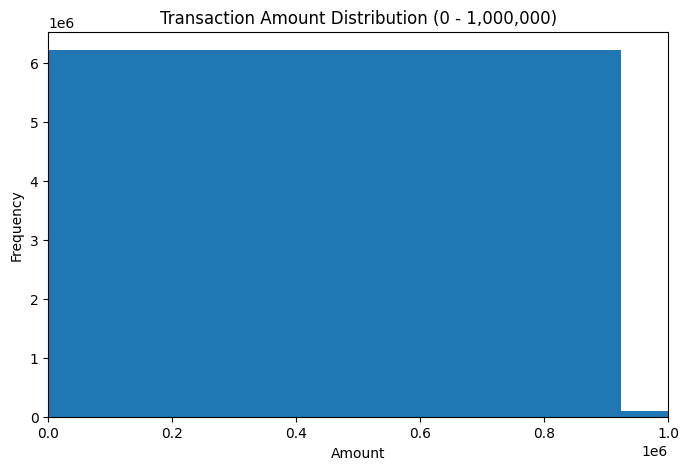

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    df["amount"],
    bins=100
)

plt.xlim(0, 1000000)   # Display transactions up to 1 million

plt.title("Transaction Amount Distribution (0 - 1,000,000)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

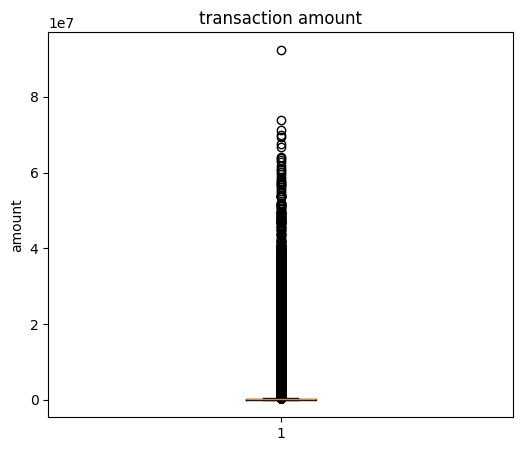

In [21]:
# box plot 

plt.figure(figsize=(6,5))

plt.boxplot(df["amount"])
plt.title("transaction amount")
plt.ylabel("amount")
plt.show()

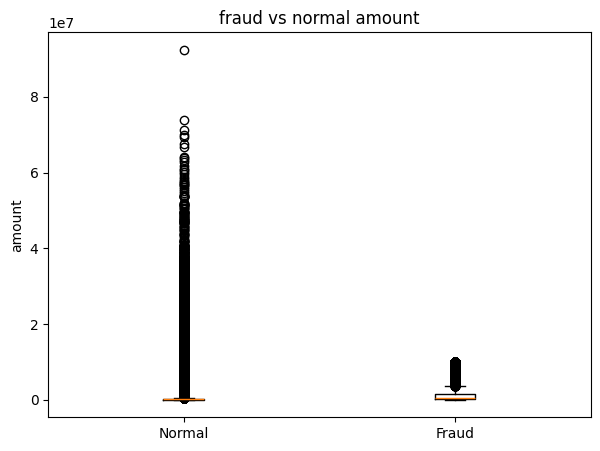

In [22]:
# fraud vs normal amount 

fraud=df[df["isfraud"]==1]["amount"]
normal=df[df["isfraud"]==0]["amount"]

plt.figure(figsize=(7,5))

plt.boxplot(
    [normal,fraud],
    tick_labels=["Normal","Fraud"]
)

plt.title("fraud vs normal amount")

plt.ylabel("amount")

plt.show()